**Machine Learning & Neural Networks Final Project**

**4.5.1 Defining the Problem and Assembling the Dataset**

The first stage of the machine learning workflow is to clearly define the prediction problem and identify the dataset that will be used. This involves determining the input data, the output to be predicted, and the type of machine learning task being addressed <sup>(1)</sup>. 

The dataset I will use in this project is the Reuters newswire dataset, which is available through the TensorFlow Keras datasets library. The dataset contains thousands of reputable news articles collected from the Reuters news agency. Each article has been labelled with the topic that the article discusses. These topic labels mean that the data will be suitable for use as testing and training data within the grander process of supervised machine learning <sup>(2)</sup>.

The input data will be the text of news articles contained in the Reuters dataset. Since neural networks cannot process raw text directly, the text must first be converted into a numerical representation. Each article is therefore encoded as a string of integers representing words from a predefined vocabulary (words are assigned numbers so that the text can be read as integers). **These strings form the input variable X**, which will be provided to the neural network during training and prediction. Neural networks process numerical data structures called tensors, so converting the text into numeric form allows the model to learn patterns from the data <sup>(3)</sup> *Note: Scalars have 0 dimensions, vectors have 1, matrices have 2 and tensors have 3 or more*.

The goal of the model is to predict the topic category of each news article. Each article in the dataset is associated with a label representing the topic that the article belongs to. **These labels form the target variable Y**. During training, the neural network receives a news article encoded as integers as input and attempts to predict the correct topic label associated with that article. ***This type of task is a multiclass classification problem.*** It is **multiclass classification** because each input examle belongs to one of several possible categories, and the model must determine which category is the most likely. In the Reuters dataset, each news article belongs to exactly one topic category, meaning that the model must assign the correct category based on the content of the article. This is as opposed to binary classification where there are only two categorical options, or the numerical outputs seen in vector regression.

In this first stage of the machine learning workflow *two key assumptions* are made.

1) The first assumption is that the topic of a news article can be predicted from the words contained in the article. In other words, it is assumed that the input text contains enough information for the model to determine the correct topic. Without this assumption, the ML model and NN might be ineffective.

2) The second assumption is that the dataset contains enough labelled examples for the NN to learn this relationship between the text and the category label. Machine learning models learn patterns that exist within the training data, so if the dataset does not contain meaningful relationships between inputs and outputs within the training data, the model may fail to achieve useful predictive performance and be ineffective or inaccurate.

These assumptions will only be validated after the model has been trained and evaluated later in the ML workflow.

Clearly defining the prediction task, the dataset, the input data, and the expected outputs ensures that the machine learning problem is well specified before model development begins.

**4.5.2 Choosing a Measure of Success**

After outlining the input, output and problem classification type, the next step in the workflow is to *determine how the success of the model will be quantified*. This is necessary because it provides an objective way to evaluate the performance of the model and to determine whether the model is improving during the training process. Without a defined metric it would not be possible to compare different models, loss functions, or determine whether the model is learning useful patterns from the data <sup>(1)</sup>.

The task in this project is to classify news articles into their correct topic category. Because each article belongs to one category from several possible classes, the problem is a multiclass classification task. For problems of this type, a commonly used evaluation metric is classification accuracy. Accuracy measures the proportion of predictions made by the model that are correct when compared with the true labels in the dataset ***(accuracy = number of correct predictions / total number of predictions)***. Additional documentation on classification metrics is also provided in the TensorFlow documentation, which describes accuracy as the fraction of predictions that are correctly classified <sup>(4)</sup>. Note: the higher the score of accuracy, the more samples were correctly predicted out of the samples which were tested.

This metric was selected based on guidance from the Deep Learning with Python workflow, which recommends accuracy as a suitable evaluation metric for balanced classification problems. We know in advance that the reuters dataset has been used extensively in machine learning research and has been defined as reasonably balanced and appropriated for ML tasks <sup>(1)</sup>. Alternative and common metrics for success of a ML task would be MSE (mean squared error) and precision though these are more suitable for tasks which output numerical values and tasks which contain one rarely occurring class within a multiclass dataset respectively. 

Although accuracy is used as the primary measure of success when evaluating the model, neural networks do not optimise accuracy directly during training. Instead, the training process minimises a loss function, which measures the difference between the predicted output of the model and the true target value. For multiclass classification problems, the commonly used loss function is categorical cross-entropy. This loss function compares the multiclass classification probability by the neural network with the correct class label and produces a numerical value representing the prediction error with a lower score being better<sup>(5)</sup>.

During the training iterations the neural network will minimise the categorical cross-entropy loss while accuracy will be monitored as the main performance metric and increase if the NN is performing correctly. Monitoring both values provides insight into how well the model is learning from the data and previous iterations, helping identify issues such as underfitting or overfitting as training progresses. By defining *accuracy as the primary measure of success* and using *categorical cross-entropy as the loss function*, the performance of the model can be evaluated consistently throughout the machine learning workflow.

**4.5.3 Deciding on an Evaluation Protocol**

Once suitable metrics for success have been decided, now we need to decide how the model will be evaluated during development. An evaluation protocol describes how the dataset being used for training and testing will be divided so that the performance of the model can be measured in a reliable way. This step is important because a ML model must be tested on data that it has not seen during training. If a model were evaluated only on the data used to train it, **the results could appear artificially good because the model may simply memorise the training examples rather than learn patterns that generalise to new data**.

There are several evaluation protocols which are commonly used. These include ***hold-out validation, k-fold cross-validation, and repeated cross-validation***. When a dataset contains a sufficiently large number of samples, the **hold-out validation** approach is often considered the most practical method because it is simple to implement and computationally efficient (1). This method involves splitting the dataset into separate subsets that are used for training, validation, and testing.

In this project the hold-out validation approach will be used as there are over 10,000 labelled examples to be split into training, testing and validation, with the training and testing sets being predefined. The training data will be used to train the neural network, while the test data will be reserved for evaluating the final model after training has been completed. During model development, a portion of the training data will be set aside as a validation set. *The validation set allows the performance of the model to be monitored while training is taking place and helps identify whether the model is improving.* It is the set against which the model is tested between iterations under current parameters.

Each subset of the data serves a different purpose. The training set is used to update the parameters of the neural network as it learns from the data through iterations. The validation set is used to monitor model performance during development and to help guide decisions about model design and parameter adjustmen. The test set is used only once the final model has been selected in order to provide an unbiased estimate of how well the model performs as a whole on previously unseen data (6). This separation helps ensure that the reported results **reflect the model’s ability to generalise rather than its ability to remember the training examples.**

Using a structured evaluation protocol such as hold-out validation is considered good practice in machine learning because it allows different model configurations to be compared fairly and helps prevent overly optimistic estimates of model performance (7). Using the same subset of data for training, testing or validation would skew results because the neural network would simply remember the data it had been trained on or had seen before. This would give an unrealistic impression of how well the model will perform on new, unseen data.

**4.5.4 Preparing the Data**

Before a neural network can be trained, the data must be prepared in a form that the model can process. Neural networks cannot work directly with raw text. Instead, the text must be converted into numerical values and arranged in tensors so that mathematical operations can be performed during training as explained in Chollet (1). The goal of this stage is therefore to transform both the input data and the labels into a numerical format that can be used by the neural network. *Note: Tensors are more appropriate because they can represent **multi-dimensional data**, allowing neural networks to process many features and many samples at the same time. Scalars, vectors, and matrices are limited to fewer dimensions, while tensors provide the flexible structure needed for complex machine learning computations.*

The news articles in the Reuters newswire dataset are **stored as sequences of integers**; integers which have been assigned to each word which appears in all the articles. We will be selecting the most commonly occurring words in order to use them for out neural network and machine learning model. With integers assigned to a word in a predefined vocabulary, the text can be processed numerically by the neural network. However, ***these sequences vary in length and cannot be used directly as input to a Dense neural network layer as every neuron would expect the same number of input values each time it runs***. 

For this reason, the sequences must be converted into fixed-length vectors through a process known as **vectorisation**. In this project the vocabulary is limited to the 10,000 most frequently occurring words in order to keep the input representation uniform and reduce noise caused by outlying and rare words. To vectorise the data we will create a vector of length 10,000, where each of the most common 10,000 words occupies a position. If a word within the 10,000 appears in the article, it's position will be switched to a value of 1, otherwise it will remain 0. This turns the article into a uniform format which the Dense neural network can process.

The first step is to load the dataset using the TensorFlow Keras datasets module. 

In [2]:
#import the Reuters dataset from TensorFlow keras
from tensorflow.keras.datasets import reuters

#load the dataset
#specify the number of words from the predefined vocabulary which will be used
#the dataset is returned as the training and testing subsets
(train_data, train_labels), (test_data, test_labels) = reuters.load_data(num_words=10000)

Now that the tensorflow dataset from reuters has been imported, we can process the data to input to out neural network.

As discussed above, the dataset stores each article as a list of numbers, where each number represents a word from the vocabulary. Because Dense neural network layers require inputs of the same size, each article must be converted into a fixed-length list of 10,000 indices, where positions corresponding to words in the article are marked with 1 and all other positions remain 0.


In [3]:
#import numpy library as standard
import numpy as np

#function to convert sequences of word indices into binary vector indices
#sequences contains the articles and dimension represents the size of the vocabulary
def vectorise_sequences(sequences, dimension=10000):

    #create 2D array of zeros by default
    #number of rows = number of articles i.e. length of sequences
    #number of columns = vocabulary size i.e. 10,000
    results = np.zeros((len(sequences), dimension)) 

    #loop through each article in the dataset
    for i, sequence in enumerate(sequences): 

        #for the current article, set the indices for present vocabulary to 1
        #if words at indices [1,4] are contained in article for example, then the array will read [1,0,0,1]
        results[i, sequence] = 1.0                   

    #return completed matrix
    return results

#apply the vectorisation function to both training and test data present in the reuters dataset
x_train = vectorise_sequences(train_data)
x_test = vectorise_sequences(test_data)

This process converts each news article into a fixed-length vector where each position indicates whether a particular word from the vocabulary appears in the article. This representation allows the neural network to process the input data efficiently and learn patterns in the words that are associated with different article categories.

The category labels must also be converted into a suitable numerical format. One-hot encoding is used so that the correct category is represented in the same vector format as the probabilities predicted by the neural network. In this format, each category label becomes a vector of zeros with a single value of 1 marking the correct category.

During training, the neural network predicts how likely the article belongs to each category, giving each one a **value between 0 and 1**. These predictions are compared with the correct category so the model can see how wrong it was and adjust itself to make better predictions next time.


In [4]:
#keras model tools
from tensorflow import keras
from tensorflow.keras import layers
#for L2 Weight Regularisation
from tensorflow.keras import regularizers

#import a utility function to perform one-hot encoding
from tensorflow.keras.utils import to_categorical

#convert integer labels into one-hot encoded vectors
y_train = to_categorical(train_labels)
y_test = to_categorical(test_labels)

This code converts the article categories into a format the neural network can understand. Each category number is turned into a list of zeros with a single 1 marking the correct category.

This is necessary because the neural network predicts a probability for every possible category, rather than just giving one category number. By converting the correct answers into the same vector format, the model can compare its predictions with the correct category during training and measure how accurate it is.

After these steps, both the article data and the category labels are stored as numerical tensors, which means they are now in the correct format to be used when training the neural network in the next stage.

In [5]:
print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)

print("Training labels shape:", y_train.shape)
print("Test labels shape:", y_test.shape)

Training data shape: (8982, 10000)
Test data shape: (2246, 10000)
Training labels shape: (8982, 46)
Test labels shape: (2246, 46)


These outputs confirm that the input data and labels have been successfully converted into tensors with consistent dimensions. If this were not the case, the neural network would not be able to operate as it requires the dimensions to be the same for mathematical operations to be carried out. 

The data is now in a suitable format for training the neural network in the next stage of the workflow.

**4.5.5 Developing a Model that Performs Better than a Baseline**

After preparing the dataset and converting the input data and category labels into tensors, the next step is to construct an initial neural network model. The objective at this stage is to develop a simple model that performs better than a naive baseline. 

*A naive baseline is a very simple prediction method, such as random guessing or always choosing the most common class, used as a minimum performance benchmark that a machine learning model should exceed.* 

Achieving performance above this baseline demonstrates that the dataset contains meaningful patterns that the model can learn, and therefore, the model shows that the input data contains meaningful information for predicting the correct label <sup>(1)</sup>.

In multiclass-classification problems it is common practice to use a softmax activation function in the final layer, because softmax converts the network’s raw outputs into a probability distribution across all possible classes. The corresponding loss function is categorical cross-entropy *(explained above)*, which measures how different the predicted probability distribution is from the correct category label. This combination of softmax and categorical cross-entropy is widely used for multiclass classification tasks in neural networks <sup>(1)</sup>, and is better suited than other means, as explained above in section 4.5.1.

The model is implemented using the Keras Sequential Model, which allows neural networks to be constructed as a simple linear stack of layers <sup>(8)</sup>. Dense layers are used to perform fully connected transformations of the input data, enabling the network to learn relationships between the numerical input vectors and the output categories. 

A Dropout layer is also included. Dropout works by randomly turning off some neurons during each training step, so the network cannot rely too heavily on any single pathway it has previously used. This forces the model to learn more general patterns in the data, which reduces the likelihood of memorising the training set and therefore helps prevent overfitting <sup>(9)</sup>.


At this stage, the network architecture is intentionally kept simple. The goal is not yet to achieve the highest possible accuracy, but rather to establish a baseline neural network that demonstrates predictive capability. Once this baseline model is trained and evaluated, further experimentation with model capacity, regularisation, and hyperparameters can be carried out in subsequent stages of the workflow.

In [6]:
#initialise a Sequential neural network - a linear stack of layers where each layer feeds into the next
model = keras.Sequential()

#add the first Dense layer
#64 neurons allows model to learn patterns while maintaining its simplicity
#ReLU (Rectified Linear Unit) introduces non-linearity, allowing the network to learn complex patterns
model.add(layers.Dense(64, activation='relu', input_shape=(10000,)))

#Dropout layer to reduce overfitting
#0.5 means that 50% of neurons are randomly switched off during each training step
#this forces the network to learn more general patterns instead of memorising training data
#can be adjusted later with other hyper parameters
model.add(layers.Dropout(0.5))

#output layer
#46 neurons correspond to the 46 possible news topic categories in the dataset
#softmax activation converts the outputs into probabilities that sum to 1
#the class label with the highest probability will be the model's predicted category
model.add(layers.Dense(46, activation='softmax'))

#compile the model so it is ready for training
#rmsprop is the optimisation algorithm that updates the network weights while learning is taking place
#categorical_crossentropy measures the difference between predicted probabilities and correct labels
#accuracy is used as a metric to monitor how many predictions are correct out of all predictionsmade
model.compile(
    optimizer='rmsprop',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

#print a summary of the model architecture
#this displays each layer, its output shape, and the number of trainable parameters (weights, biases etc.)
model.summary()

C:\Users\Alex\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │         640,064 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 46)                  │           2,990 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 643,054 (2.45 MB)

 Trainable params: 643,054 (2.45 MB)

 Non-trainable params: 0 (0.00 B)

The model summary confirms that the neural network has been successfully constructed. The output shape **(None, 64)** in the first Dense layer indicates that each input article is transformed into a vector of 64 features, while the value **None** represents a flexible batch size, meaning the network can process any number of articles at once during training or prediction. The summary also shows the number of trainable parameters in each layer, which represent the weights and biases that will be adjusted during training *automatically by the optimizer (rmsprop)* in order to minimise the loss and improve prediction accuracy. *Note: the 2.45 MB indicates the approximate amount of memory required to store all the trainable parameters (weights and biases) of the neural network.*


**4.5.6 Developing a Model that Overfits**

The purpose of this stage is to determine whether the baseline model has sufficient capacity to learn the structure of the dataset. In machine learning, the ideal model lies between underfitting *(a model that is too simple to capture patterns in the data)* and overfitting *(a model that memorises the training data but performs poorly on unseen data)*. In order to find this balance, it is useful to deliberately construct a model that overfits.

A model can be encouraged to overfit by increasing its capacity, which means allowing it to learn more complex relationships within the training data. This can be achieved by increasing the number of neurons in hidden layers, adding additional layers, or training the model for more epochs. When a model begins to overfit, the training loss continues to decrease while the validation loss begins to increase, **indicating that the network is memorising the training data rather than generalising to unseen samples.**

In this experiment, the architecture of the baseline model is expanded by increasing the number of neurons in the hidden layer. This increases the number of trainable parameters and therefore the model’s ability to fit the training data. The objective is to observe whether the model begins to overfit when its capacity is increased.

In [7]:
#construct a larger neural network to test model capacity
model_overfit = keras.Sequential()

#double the number of neurons to increase model complexity
model_overfit.add(layers.Dense(128, activation='relu', input_shape=(10000,)))

#remove dropout to reduce regularisation and encourage overfitting
model_overfit.add(layers.Dense(46, activation='softmax'))

#compile the model
model_overfit.compile(
    optimizer='rmsprop',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

#print architecture summary
model_overfit.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                      │ (None, 128)                 │       1,280,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 46)                  │           5,934 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,286,062 (4.91 MB)

 Trainable params: 1,286,062 (4.91 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history_overfit = model_overfit.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=512,
    validation_split=0.2
)

Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 128ms/step - accuracy: 0.5553 - loss: 2.4447 - val_accuracy: 0.6750 - val_loss: 1.6618
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.7283 - loss: 1.3483 - val_accuracy: 0.7095 - val_loss: 1.2857
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.7915 - loss: 1.0054 - val_accuracy: 0.7596 - val_loss: 1.1098
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.8370 - loss: 0.7995 - val_accuracy: 0.7813 - val_loss: 1.0086
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - accuracy: 0.8679 - loss: 0.6559 - val_accuracy: 0.7902 - val_loss: 0.9511
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.8960 - loss: 0.5449 - val_accuracy: 0.7858 - val_loss: 0.9217
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.9101 - loss: 0.4567 - val_accuracy: 0.8024 - val_loss: 0.8882
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.9233 - loss: 0.3871 - val_accuracy: 0.8108 - 

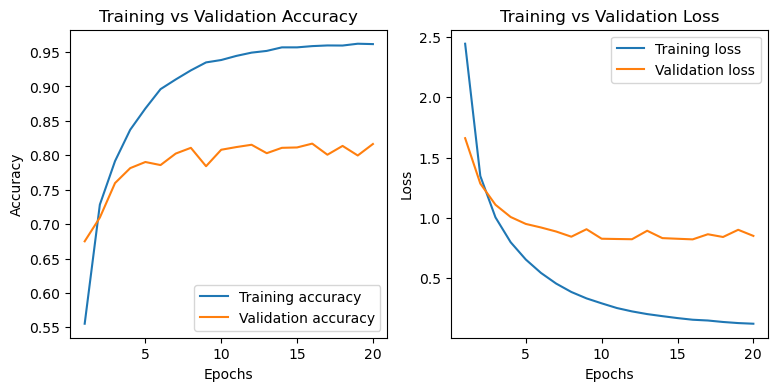

In [9]:
import matplotlib.pyplot as plt

#extract values from training history
acc = history_overfit.history['accuracy']
val_acc = history_overfit.history['val_accuracy']
loss = history_overfit.history['loss']
val_loss = history_overfit.history['val_loss']

epochs = range(1, len(acc) + 1)

#create two plots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9,4))

#accuracy plot
ax1.plot(epochs, acc, label='Training accuracy')
ax1.plot(epochs, val_acc, label='Validation accuracy')
ax1.set_title('Training vs Validation Accuracy')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()

#loss plot
ax2.plot(epochs, loss, label='Training loss')
ax2.plot(epochs, val_loss, label='Validation loss')
ax2.set_title('Training vs Validation Loss')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()

plt.show()

The training and validation accuracy and loss graphs above illustrate how the model’s performance evolves over the 20 training epochs. The **training accuracy** increases steadily from approximately **0.56 in the first epoch to around 0.96 by epoch 20**, while the **training loss** decreases consistently from about **2.46 to roughly 0.12**. This trend shows that the model is progressively fitting the training data and learning the patterns present in the dataset.

However, the validation curves display a different pattern. The validation accuracy improves during the early stages of training, **increasing from approximately 0.64 to around 0.81**, but **after roughly 9 epochs it begins to stabilise**, fluctuating within a narrow range for the remainder of training. At the same time, the validation loss initially decreases but then begins to increase gradually after around **epoch 10**, rising from roughly **0.82 to about 0.87** by the final epoch. This increase in validation loss suggests that the model is beginning to memorise the training data, because although it continues fitting the training data more closely, its prediction error on unseen validation data begins to worsen, indicating that the patterns being learned are becoming specific to the training set rather than generalisable.

The divergence between the training and validation curves visible in the graphs indicates the onset of **overfitting**. While the model continues to improve its performance on the training dataset, these improvements are not reflected in the validation results, **which represent unseen data**. Instead, the network begins to learn increasingly specific patterns in the training data such as noise or irregularities which doesn't improve the model as a whole. As a result, training accuracy continues to increase while validation performance remains relatively stable and validation loss begins to rise. This behaviour demonstrates that the model has sufficient capacity to fit the training data and confirms that increasing model capacity can lead to overfitting.

The optimal points for accuracy and loss occur at slightly different epochs because they measure different aspects of model performance. In this case, the optimal epoch for validation accuracy appears to occur around epoch 9 or 10, while the lowest validation loss occurs later at approximately epoch 12.



**4.5.7 Regularizing the Model and Tuning Hyperparameters**


Having demonstrated in the previous section that increasing the capacity of the neural network by increasing the number of active neurons leads to overfitting, the next stage of the workflow is to apply regularisation techniques and tune the model’s hyperparameters in order to improve generalisation performance. 

The training curves from the overfitting experiment showed that while training accuracy continued to improve, validation performance stabilised and validation loss began to increase after approximately epoch 12, indicating that the model had begun to memorise patterns specific to the training data rather than learning generalisable features. To address this behaviour, a series of controlled experiments will be conducted to determine a more balanced model configuration. 

First, the strength of dropout regularisation will be adjusted to examine how different dropout rates affect generalisation. 

Secondly, L2 weight regularisation will be introduced to constrain the magnitude of network weights and encourage simpler representations. *L2 weight regularisation penalises large weights during training, encouraging the model to learn simpler patterns and reducing overfitting.* 

***A third experiment about neurons amount in the hidden dense layer had to be aborted because my kernel was fried and I was running out of time***

**4.5.7.1 Experiment 1 - Adjusting the Dropout Regularisation Strength**

The first experiment examines whether the strength of dropout regularisation used in the baseline model is appropriate. In the baseline architecture a dropout rate of **0.5** was used, meaning that half of the neurons in the hidden layer are randomly deactivated during each training step. While dropout helps reduce overfitting by preventing the network from relying too heavily on individual neurons, an excessively high dropout rate can also remove too much information during training and reduce the model’s learning capacity.

To investigate this, the dropout rate will be adjusted while keeping the rest of the model architecture unchanged. The hidden layer will continue to use **64 neurons with ReLU activation**, and the output layer will remain a **46-unit softmax layer** for multiclass classification. The only modification will be altering the dropout rate and setting it to **0.3, 0.5, 0.8** in order to evaluate the strengths and weaknesses shown from a range of dropouts.

The model will be trained using the same training configuration as previous experiments, including the same number of epochs, batch size, and validation split. Keeping these conditions constant ensures that any changes in training behaviour can be attributed to the adjusted dropout rate.

After training, the training and validation accuracy and loss will be plotted again. These results will be compared with those observed in the previous section in order to determine whether the adjusted dropout rate produces a better balance between fitting the training data and maintaining stable validation performance.


In [10]:
#dropout values to test
dropout_rates = [0.1, 0.3, 0.5, 0.8]

#empty data structure to store training histories
histories_dropout = {}

#loop for each dropout value
for rate in dropout_rates:
    
    print(f"\nTraining model with dropout rate = {rate}")
    
    model_dropout = keras.Sequential()
    
    #first Dense layer as before
    model_dropout.add(layers.Dense(64, activation='relu', input_shape=(10000,)))
    
    #dropout layer as before with varying rate in each loop
    model_dropout.add(layers.Dropout(rate))
    
    #output layer
    model_dropout.add(layers.Dense(46, activation='softmax'))
    
    #compile model
    model_dropout.compile(
        optimizer='rmsprop',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    #train model
    history = model_dropout.fit(
        x_train,
        y_train,
        epochs=20,
        batch_size=512,
        validation_split=0.2
    )
    
    #store results
    histories_dropout[rate] = history


Training model with dropout rate = 0.1
Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.5116 - loss: 2.8065 - val_accuracy: 0.6021 - val_loss: 2.0411
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6668 - loss: 1.7442 - val_accuracy: 0.6978 - val_loss: 1.5348
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7350 - loss: 1.3183 - val_accuracy: 0.7251 - val_loss: 1.3094
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7733 - loss: 1.0816 - val_accuracy: 0.7585 - val_loss: 1.1605
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.8134 - loss: 0.9122 - val_accuracy: 0.7602 - val_loss: 1.0789
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8374 - loss: 0.7848 - val_accuracy: 0.7813 - val_loss: 1.0091
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8622 - loss: 0.6836 - val_accuracy: 0.7841 - val_loss: 0.9646
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8786 -

Now let's plot the graphs and evaluate

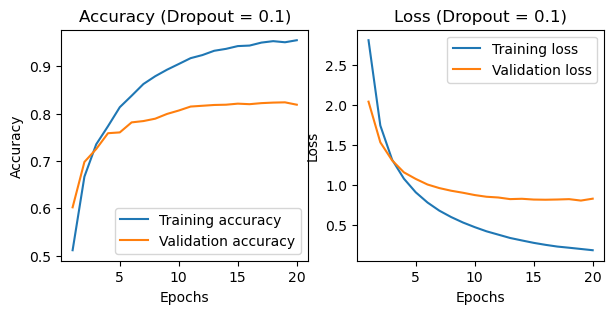

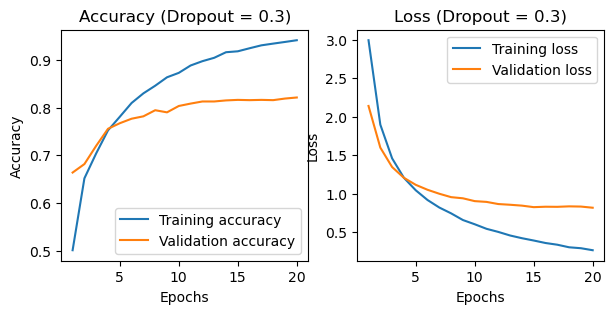

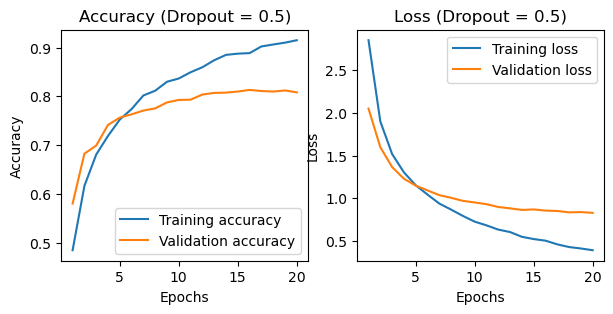

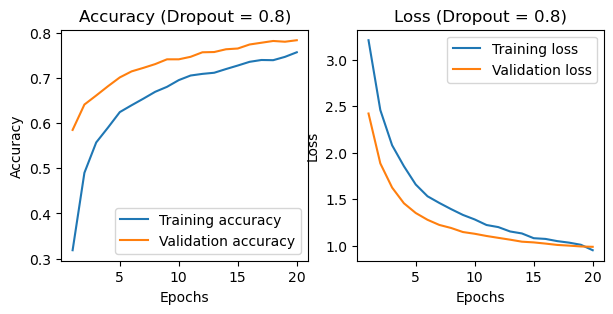

In [11]:
for rate, history in histories_dropout.items():
    
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)
    
    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(7,3))
    
    ax1.plot(epochs, acc, label='Training accuracy')
    ax1.plot(epochs, val_acc, label='Validation accuracy')
    ax1.set_title(f'Accuracy (Dropout = {rate})')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    
    ax2.plot(epochs, loss, label='Training loss')
    ax2.plot(epochs, val_loss, label='Validation loss')
    ax2.set_title(f'Loss (Dropout = {rate})')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Loss')
    ax2.legend()
    
    plt.show()

The results in the table show how different dropout levels influence the model’s learning behaviour and its ability to generalise to unseen data.

When the **dropout rate is 0.1**, the model reaches the highest training accuracy at approximately **0.95**, indicating that it fits the training data very closely. Validation accuracy peaks at around **0.815**, while validation loss reaches a minimum of roughly **0.816** before increasing slightly in the final epochs. This pattern suggests that the model is learning meaningful patterns, but the relatively low level of regularisation is not sufficient to fully control overfitting. The visible gap between training and validation performance indicates that some degree of overfitting is still present.

With a **dropout rate of 0.3**, the model produces the most balanced results. Training accuracy reaches approximately **0.94**, while validation accuracy improves slightly to around **0.82**, the highest value observed among the tested configurations. Validation loss also decreases steadily during training and remains relatively stable in later epochs. This behaviour suggests that the model still has enough capacity to learn useful patterns while the regularisation helps prevent it from memorising the training data too closely. Overall, this configuration appears to offer the most effective balance between learning capacity and generalisation.

Increasing the dropout rate to **0.5** introduces stronger regularisation. Training accuracy decreases slightly to around **0.92**, while validation accuracy reaches approximately **0.81**. Validation loss also remains somewhat higher compared with the 0.3 configuration. These results indicate that although stronger dropout can reduce overfitting, it may also begin to limit the model’s ability to capture the full structure of the dataset.

The configuration with a **dropout rate of 0.8** demonstrates the effects of excessive regularisation. Training accuracy only reaches about **0.75**, and validation accuracy remains below **0.79**, with validation loss staying noticeably higher throughout training. This behaviour is characteristic of **underfitting**, where too many neurons are disabled and the network struggles to learn the important patterns present in the data.

With all considered, these results highlight the trade-off between model capacity and regularisation strength. Lower dropout rates allow the network to learn more complex relationships but increase the likelihood of overfitting, while very high dropout rates restrict learning and lead to underfitting. Among the configurations tested, a **dropout rate of approximately 0.3** provides the most effective balance, achieving the highest validation accuracy while maintaining stable validation loss. For this reason, this configuration will be used as the foundation for further model tuning in the subsequent experiments.


**4.5.7.2 Experiment 2 - L2 Weight Regularisation**

After identifying an appropriate dropout rate in the previous experiment, the next step is to examine whether additional regularisation can further improve the model’s generalisation performance. One commonly used technique is **L2 weight regularisation**, which discourages the model from relying too heavily on any single connection between neurons during training. In simple terms, it penalises and discourages the model when weights become very large, encouraging the network to keep weight values smaller and learn simpler patterns from the data <sup>(1)</sup>. This helps the model focus on the most meaningful relationships within the dataset rather than memorising specific details from the training data. In short, ***pattern recognition is encouraged, but only to a point.***

In this experiment, the architecture of the model will remain unchanged in order to isolate the effect of L2 weight regularisation. The hidden layer will continue to use **64 neurons with a ReLU activation function**, and the output layer will remain a **46-unit softmax layer** for multiclass classification. The dropout rate will also remain fixed at **0.3**, as this configuration produced the best balance between training and validation performance in the previous experiment. *To investigate the effect of L2 regularisation strength, several values of the L2 coefficient will be tested in separate training runs.*

The model will be trained using the same configuration as earlier experiments, including the same **number of epochs, batch size, and validation split**. Keeping these conditions constant ensures that any differences in performance can be attributed to the introduction of L2 weight regularisation rather than changes in the training procedure.

After training, the training and validation accuracy and loss will again be plotted and compared with the results from the dropout experiments. This comparison will help determine whether combining **dropout and L2 regularisation** produces more stable validation behaviour and improves the model’s ability to generalise to unseen data.


In [12]:
#L2 regularisation strengths to test
l2_values = [0, 0.00025, 0.0005, 0.001]

#store training histories
histories_l2 = {}

for value in l2_values:

    print(f"\nTraining model with L2 regularisation = {value}")

    #construct model
    model_l2 = keras.Sequential()

    #hidden layer with L2 penalty added
    model_l2.add(
        layers.Dense(
            64,
            activation='relu',
            input_shape=(10000,),
            kernel_regularizer=regularizers.l2(value)
        )
    )

    #best dropout rate from previous experiment
    model_l2.add(layers.Dropout(0.3))

    #unchanged output layer
    model_l2.add(layers.Dense(46, activation='softmax'))

    #unchanged compile model
    model_l2.compile(
        optimizer='rmsprop',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    #unchanged train model
    history = model_l2.fit(
        x_train,
        y_train,
        epochs=20,
        batch_size=512,
        validation_split=0.2
    )
    
    histories_l2[value] = history


Training model with L2 regularisation = 0
Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 99ms/step - accuracy: 0.5211 - loss: 2.7909 - val_accuracy: 0.6494 - val_loss: 1.9900
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.6537 - loss: 1.7848 - val_accuracy: 0.6884 - val_loss: 1.5373
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.7045 - loss: 1.3890 - val_accuracy: 0.7184 - val_loss: 1.3187
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.7513 - loss: 1.1616 - val_accuracy: 0.7396 - val_loss: 1.1999
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.7822 - loss: 1.0143 - val_accuracy: 0.7535 - val_loss: 1.1216
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.8056 - loss: 0.8965 - val_accuracy: 0.7646 - val_loss: 1.0575
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.8310 - loss: 0.8027 - val_accuracy: 0.7813 - val_loss: 1.0063
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.845

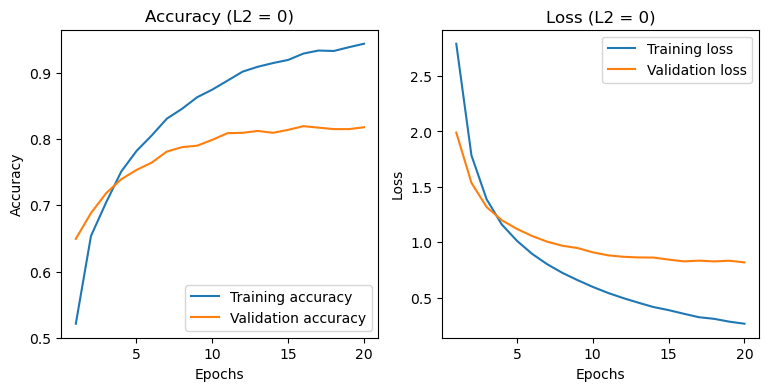

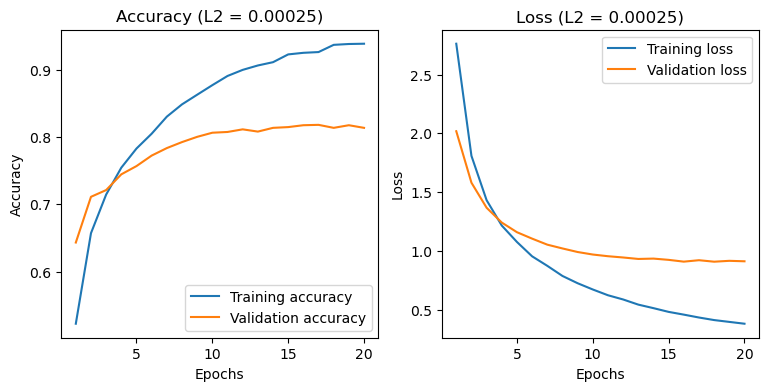

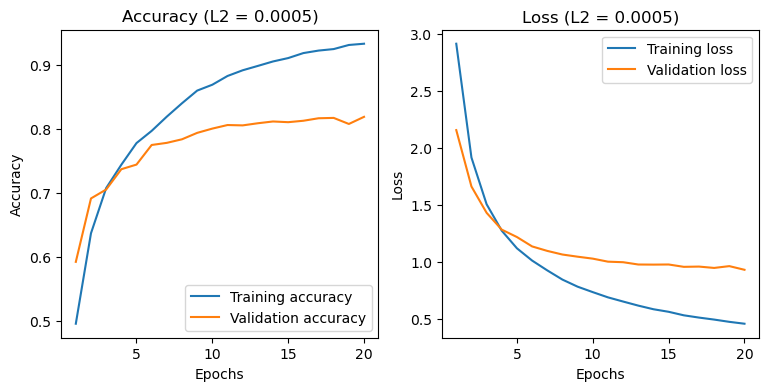

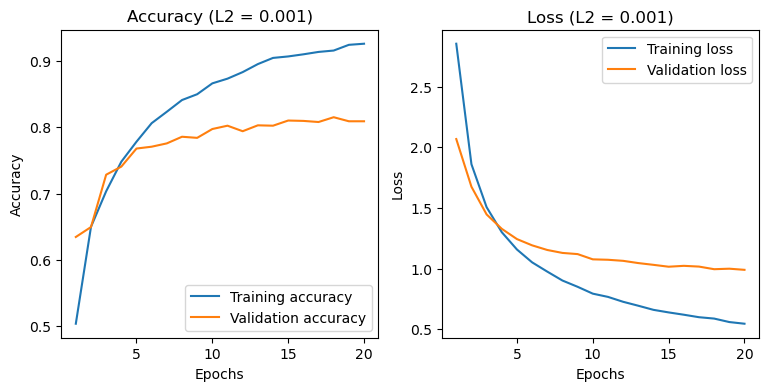

In [13]:
for value, history in histories_l2.items():

    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(1, len(acc) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9,4))

    #accuracy plot
    ax1.plot(epochs, acc, label='Training accuracy')
    ax1.plot(epochs, val_acc, label='Validation accuracy')
    ax1.set_title(f'Accuracy (L2 = {value})')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Accuracy')
    ax1.legend()

    #loss plot
    ax2.plot(epochs, loss, label='Training loss')
    ax2.plot(epochs, val_loss, label='Validation loss')
    ax2.set_title(f'Loss (L2 = {value})')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Loss')
    ax2.legend()

    plt.show()

Initially, three different values were selected for the L2 weight regularisation experiment. However, the smallest value produced the strongest validation results. When a new, smaller value was introduced, that again produced the best performance. This pattern suggested that the optimal value might be even closer to zero. To investigate this further, the experiment was repeated a third time with **no L2 regularisation** applied, allowing the model to be compared directly with a version that relied only on dropout for regularisation.

Including this additional run provides a clearer view of how the different L2 strengths influence model behaviour. Overall, the results suggest that **very small L2 penalties do not significantly improve performance when dropout is already present**, and in some cases may slightly limit the model’s ability to learn.

When **no L2 regularisation** is applied, the model performs strongly. Training accuracy increases steadily throughout the epochs and finishes at approximately **0.94**, while validation accuracy reaches around **0.82**. Validation loss ends at roughly **0.82**, which is the lowest value observed among the tested configurations. This demonstrates that the model is able to learn meaningful patterns from the training data while still maintaining stable performance on unseen validation samples.

Introducing a small penalty with **L2 = 0.00025** produces very similar behaviour, but with slightly weaker validation performance. Training accuracy again approaches **0.94**, but validation accuracy settles closer to **0.81**, and validation loss remains marginally higher than in the configuration without L2 suggesting that the additional constraint on the weights does not provide a clear improvement in generalisation and may slightly restrict the optimisation process.

When the regularisation strength is increased to **0.0005**, this effect becomes more noticeable. Although training accuracy still reaches a high level, validation accuracy does not improve and remains around **0.81**, while validation loss is consistently higher than the baseline model. This shows that the stronger penalty begins to limit the model’s ability to capture more detailed relationships within the dataset.

**L2 = 0.001** leads to the worst relative performance. While the model still learns effectively, it seems training accuracy increases more slowly and validation loss remains higher throughout the training process. This pattern suggests that the stronger penalty constrains the network’s weights too heavily, reducing its capacity to represent the structure of the data.

Taken together, these results indicate that **adding L2 regularisation does not provide a clear benefit for this model when dropout is already being used**. In fact, the configuration without L2 regularisation produced the best overall model performance. This suggests that the dropout layer introduced earlier already provides sufficient regularisation, and that adding further penalties to the weights may unnecessarily restrict the model’s learning capacity and add no benefit whatsoever.


**Final Model Evaluation**

In [14]:
#final model configuration identified from experiments
final_model = keras.Sequential()

final_model.add(
    layers.Dense(64, activation='relu', input_shape=(10000,))
)

final_model.add(layers.Dropout(0.3))

final_model.add(layers.Dense(46, activation='softmax'))

final_model.compile(
    optimizer='rmsprop',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

#train final model on full training data
final_model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=512
)

#evaluate on test set
test_loss, test_acc = final_model.evaluate(x_test, y_test)

print("Test accuracy:", test_acc)
print("Test loss:", test_loss)

Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.5105 - loss: 2.6760
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.6693 - loss: 1.6664
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7296 - loss: 1.2876
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7731 - loss: 1.0578
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8059 - loss: 0.9099
Epoch 6/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.8311 - loss: 0.7976
Epoch 7/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8536 - loss: 0.7102
Epoch 8/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.8692 - loss: 0.6281
Epoch 9/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8798 - loss: 0.5682
Epoch 10/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8926 - loss: 0.5133
Epoch 11/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9028 - loss: 0.4662
Epoch 12/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy:

The final model was built using the configuration that performed best during the tuning stage: **64 hidden units**, a **dropout rate of 0.3**, and **no L2 regularisation**. Once this configuration had been identified, the model was trained again on the full training dataset and then evaluated on the **test set**, which contains data the model had not seen before.

When tested, the model achieved an **accuracy of about 0.81** with a **test loss of roughly 0.85**. These results are very similar to the validation performance observed during training, where validation accuracy stabilised at around **0.82**. Because the test results are so close to the validation results, it suggests that the model is not simply memorising the training data and is able to perform reasonably well on new, unseen examples.

Overall, this final evaluation supports the earlier experiments and indicates that the chosen configuration provides a sensible balance between learning useful patterns and avoiding overfitting.


**4.5.7.3 - Conclusion**

This section explored ways to improve the model by experimenting with different regularisation techniques and observing how these changes affected performance on unseen data. The goal was to find a configuration that allows the model to learn useful patterns from the training data while avoiding the tendency to simply memorise it.

The first experiment investigated the effect of different **dropout rates**. The results showed that dropout has a clear influence on how the model learns. When the dropout rate was too high, too many neurons were disabled during training and the model struggled to capture the important patterns in the data. When the rate was too low, the model fitted the training data very closely and the gap between training and validation performance became more noticeable. Among the configurations tested, a **dropout rate of 0.3** produced the most balanced behaviour, allowing the model to learn effectively while keeping validation performance stable.

The second experiment examined whether introducing **L2 weight regularisation** could further improve the model’s ability to generalise. Several values were tested, gradually reducing the strength of the penalty applied to the network weights. However, the results showed that adding L2 regularisation did not provide any clear improvement over the model that already used dropout. In fact, stronger penalties slightly limited the model’s ability to learn the structure of the dataset.

Taken together, the experiments suggest that the most effective configuration for this task is the model that uses **a dropout rate of 0.3 with no additional L2 regularisation**. This setup produced the strongest validation performance while maintaining stable learning behaviour. More broadly, these experiments illustrate how relatively small adjustments to regularisation can noticeably influence model behaviour, and highlight the importance of testing different configurations when working toward a model that both learns effectively and generalises well to new data.


**References**


(1) Chollet, F., 2018. Deep Learning with Python. 1st ed. Shelter Island, NY: Manning Publications.

(2) TensorFlow, Reuters dataset – Available at: https://www.tensorflow.org/api_docs/python/tf/keras/datasets/reuters
 (Accessed: 1 March 2026).

(3) TensorFlow, Text classification with TensorFlow and Keras. Available at: https://www.tensorflow.org/tutorials/keras/text_classification
 (Accessed: 1 March 2026).

(4) TensorFlow, Classification metrics. Available at: https://www.tensorflow.org
 (Accessed: 1 March 2026).

(5) Sentdex, Neural Networks from Scratch. Available at: https://www.youtube.com/watch?v=dEXPMQXoiLc
 (Accessed: 2 March 2026)

(6) TensorFlow, Training and evaluation in Keras. Available at: https://www.tensorflow.org/guide/keras/training_with_built_in_methods (Accessed: 2 March 2026).

(7) Chandan, G., 2022. Training, Testing, Validation Datasets and Cross-Validation. Available at: https://gschandan.dev/posts/2022-04-27-testing-validation.html
 (Accessed: 3 March 2026).

(8) TensorFlow, 2024. Keras Sequential model documentation. Available at: https://keras.io/api/models/sequential/
 (Accessed: 3 March 2026).

(9) TensorFlow, Dropout layer. Available at: https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dropout
 (Accessed: 3 March 2026) 